In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Default.csv')

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [15]:
print(df.describe())

                  ID      year   loan_amount  rate_of_interest  \
count  148670.000000  148670.0  1.486700e+05     112231.000000   
mean    99224.500000    2019.0  3.311177e+05          4.045476   
std     42917.476598       0.0  1.839093e+05          0.561391   
min     24890.000000    2019.0  1.650000e+04          0.000000   
25%     62057.250000    2019.0  1.965000e+05          3.625000   
50%     99224.500000    2019.0  2.965000e+05          3.990000   
75%    136391.750000    2019.0  4.365000e+05          4.375000   
max    173559.000000    2019.0  3.576500e+06          8.000000   

       Interest_rate_spread  Upfront_charges           term  property_value  \
count         112031.000000    109028.000000  148629.000000    1.335720e+05   
mean               0.441656      3224.996127     335.136582    4.978935e+05   
std                0.513043      3251.121510      58.409084    3.599353e+05   
min               -3.638000         0.000000      96.000000    8.000000e+03   
25%       

In [16]:
print(df.head())

      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \
0          EXP           758                 

In [17]:
print(df.tail())

            ID  year loan_limit             Gender approv_in_adv loan_type  \
148665  173555  2019         cf  Sex Not Available         nopre     type1   
148666  173556  2019         cf               Male         nopre     type1   
148667  173557  2019         cf               Male         nopre     type1   
148668  173558  2019         cf             Female         nopre     type1   
148669  173559  2019         cf             Female         nopre     type1   

       loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
148665           p3                l1        nopc                  nob/c  ...   
148666           p1                l1        nopc                  nob/c  ...   
148667           p4                l1        nopc                  nob/c  ...   
148668           p4                l1        nopc                  nob/c  ...   
148669           p3                l1        nopc                  nob/c  ...   

        credit_type  Credit_Score  co-applic

In [18]:
print("DataFrame Shape:", df.shape)

DataFrame Shape: (148670, 34)


In [19]:
print("DataFrame Columns:", df.columns.tolist())

DataFrame Columns: ['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


In [20]:
# 3️ Missing value inspection & filling
def find_missing_values(df):
    missing_values = df.isnull().sum()
    return missing_values[missing_values > 0]

print("Missing values before:\n", find_missing_values(df))

Missing values before:
 loan_limit                    3344
approv_in_adv                  908
loan_purpose                   134
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
property_value               15098
income                        9150
age                            200
submission_of_application      200
LTV                          15098
dtir1                        24121
dtype: int64


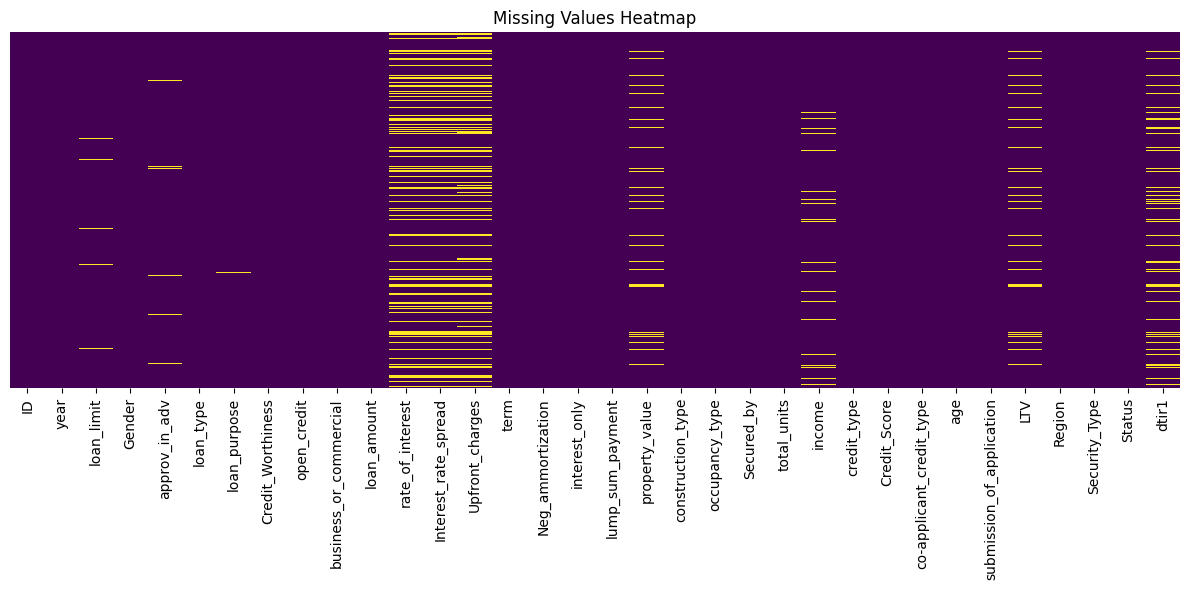

In [21]:
# 3.1 Heatmap of missing values
def plot_missing_values_heatmap(df):
    """Plot a heatmap showing missing values in the DataFrame."""
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.tight_layout()
    plt.show()
plot_missing_values_heatmap(df)

In [22]:
def fill_missing_values(df):
    """Fill missing values with median for numeric and mode for categorical."""
    for col in df.columns:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
        else:
            fill_val = df[col].median()
        df[col] = df[col].fillna(fill_val)

    return df

df = fill_missing_values(df)
print("Missing values after:\n", find_missing_values(df))

Missing values after:
 Series([], dtype: int64)


In [23]:
# 4️ Remove duplicates
df = df.drop_duplicates()

# 5️ Drop irrelevant columns (safe version)
def drop_irrelevant_columns(df, target='Status', missing_thresh=0.9, low_var_thresh=0.01):
    to_drop = []
    for col in df.columns:
        if col == target:
            continue
        missing_ratio = df[col].isnull().mean()
        if missing_ratio > missing_thresh:
            to_drop.append(col)
        elif df[col].nunique() <= 1:
            to_drop.append(col)
        elif df[col].nunique() / len(df) < low_var_thresh and df[col].nunique() > 2:
            to_drop.append(col)
    df.drop(columns=to_drop, inplace=True)
    print(f"Dropped {len(to_drop)} low-value/missing columns: {to_drop}")
    return df

df = drop_irrelevant_columns(df)

Dropped 16 low-value/missing columns: ['year', 'Gender', 'loan_type', 'loan_purpose', 'loan_amount', 'rate_of_interest', 'term', 'property_value', 'occupancy_type', 'total_units', 'income', 'credit_type', 'Credit_Score', 'age', 'Region', 'dtir1']


In [24]:
# 6️ Data type conversion
def convert_data_types(df):
    """Convert text to numeric or category as appropriate."""
    binary_map = {'Yes': 1, 'No': 0, 'Y': 1, 'N': 0, 'True': 1, 'False': 0}
    df.replace(binary_map, inplace=True)

    for col in df.select_dtypes(include=['object']).columns:
        if df[col].nunique() <= 20:
            df[col] = df[col].astype('category')

    # Ensure Status is int
    if 'Status' in df.columns:
        df['Status'] = pd.to_numeric(df['Status'], errors='coerce').fillna(0).astype(int)

    return df

df = convert_data_types(df)

In [25]:
# 7️ Encode categorical variables
def encode_categorical_variables(df, target='Status'):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    categorical_cols = [c for c in categorical_cols if c != target]
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    return df

df = encode_categorical_variables(df)

In [26]:
# 8 Handle outliers (before scaling)
def remove_outliers(df, target='Status', iqr_factor=1.5):
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target]
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower, upper)  # Cap instead of remove
    return df

df = remove_outliers(df)


In [27]:
# 9 Scale numeric features (after outlier handling)
from sklearn.preprocessing import MinMaxScaler
def scale_numeric_features(df, target='Status'):
    scaler = MinMaxScaler()
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target]
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df

df = scale_numeric_features(df)



In [28]:
# 10 Save cleaned data
def save_cleaned_data(df, filepath):
    df.to_csv(filepath, index=False)
    print(f" Cleaned data saved to: {filepath}")

save_cleaned_data(df, "/content/drive/MyDrive/Colab Notebooks/Cleaned_Loan_Default.csv")

# 11 Reload cleaned data
def load_cleaned_data(filepath):
    return pd.read_csv(filepath)

df = load_cleaned_data("/content/drive/MyDrive/Colab Notebooks/Cleaned_Loan_Default.csv")


 Cleaned data saved to: /content/drive/MyDrive/Colab Notebooks/Cleaned_Loan_Default.csv


In [29]:
# 12 Analyze cleaned data
def analyze_data(df):
    print(" Data Summary:\n", df.describe())
    print("\n Target Value Counts:\n", df['Status'].value_counts(normalize=True))
    print("\n Remaining Dtypes:\n", df.dtypes.value_counts())
    print("\n Final Shape:", df.shape)

analyze_data(df)

 Data Summary:
                   ID  Interest_rate_spread  Upfront_charges            LTV  \
count  148670.000000         148670.000000    148670.000000  148670.000000   
mean        0.500000              0.512288         0.366310       0.488527   
std         0.288678              0.235334         0.280611       0.200175   
min         0.000000              0.000000         0.000000       0.000000   
25%         0.250000              0.375000         0.159261       0.375000   
50%         0.500000              0.494099         0.330811       0.513137   
75%         0.750000              0.625000         0.495557       0.625000   
max         1.000000              1.000000         1.000000       1.000000   

              Status  
count  148670.000000  
mean        0.246445  
std         0.430942  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         1.000000  

 Target Value Counts:
 Status
0    0.753555
1    0.246445
Name: proportio

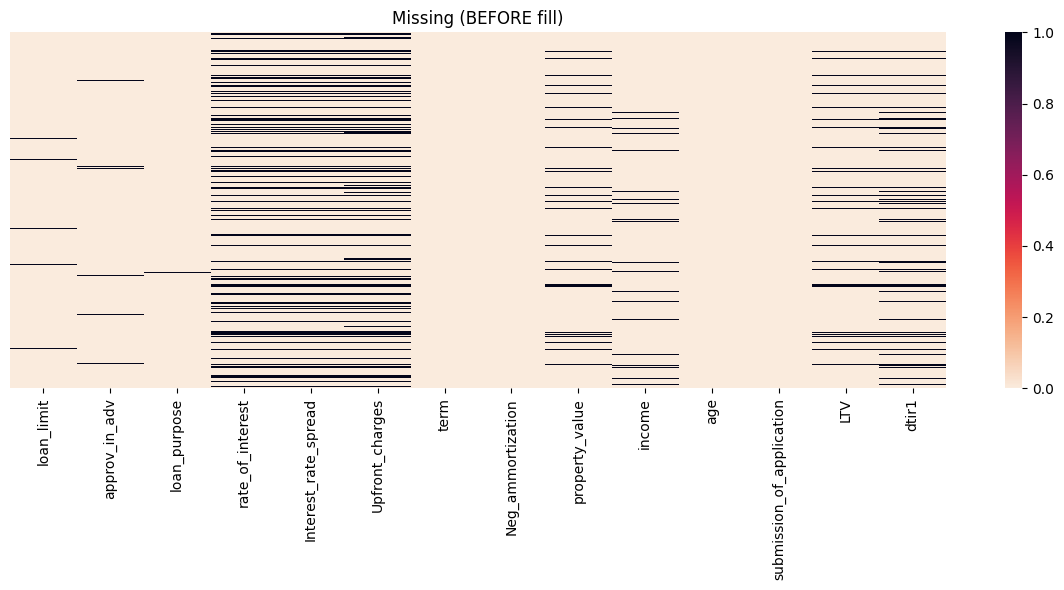

 No missing values to show.


In [30]:
# Load RAW once
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_Default.csv')

def plot_missing_values_heatmap(df, title='Missing Values Heatmap'):
    na_cols = df.columns[df.isna().any()]
    if len(na_cols) == 0:
        print(" No missing values to show.")
        return
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[na_cols].isna(), cbar=True, yticklabels=False, cmap='rocket_r', vmin=0, vmax=1)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# BEFORE imputation
plot_missing_values_heatmap(df_raw, title='Missing (BEFORE fill)')

df_clean = fill_missing_values(df_raw.copy())

# AFTER imputation
plot_missing_values_heatmap(df_clean, title='Missing (AFTER fill)')


In [31]:
# 13 Numeric Summarystatistics
def numeric_summary(df):
    """Return summary statistics for numeric columns in the DataFrame."""
    numeric_cols = df.select_dtypes(include=[np.number])
    return numeric_cols.describe()
numeric_stats = numeric_summary(df)
print("Numeric Summary Statistics:\n", numeric_stats)



Numeric Summary Statistics:
                   ID  Interest_rate_spread  Upfront_charges            LTV  \
count  148670.000000         148670.000000    148670.000000  148670.000000   
mean        0.500000              0.512288         0.366310       0.488527   
std         0.288678              0.235334         0.280611       0.200175   
min         0.000000              0.000000         0.000000       0.000000   
25%         0.250000              0.375000         0.159261       0.375000   
50%         0.500000              0.494099         0.330811       0.513137   
75%         0.750000              0.625000         0.495557       0.625000   
max         1.000000              1.000000         1.000000       1.000000   

              Status  
count  148670.000000  
mean        0.246445  
std         0.430942  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         1.000000  


In [32]:
# 14 Categorical Summary statistics
def categorical_summary(df, verbose=True):
    """Return summary stats for categorical columns; handle none-present case."""
    cats = df.select_dtypes(include=['object', 'category'])
    if cats.shape[1] == 0:
        if verbose:
            print(" No categorical columns found (likely after encoding).")
        # Return empty DataFrame to avoid ValueError
        return pd.DataFrame(columns=["count","unique","top","freq"])
    summary = cats.describe()
    if verbose:
        print("Categorical Summary Statistics:\n", summary)
    return summary




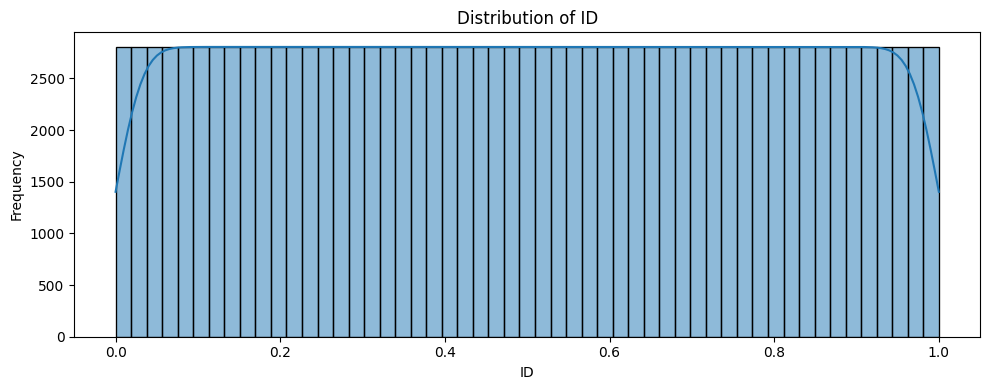

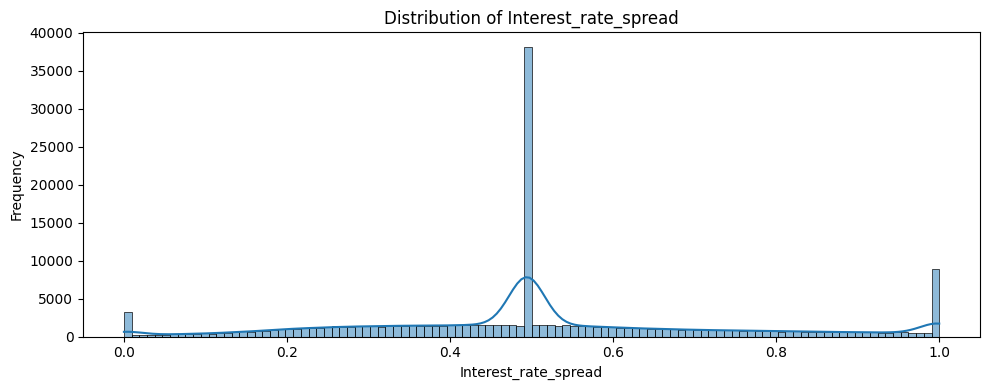

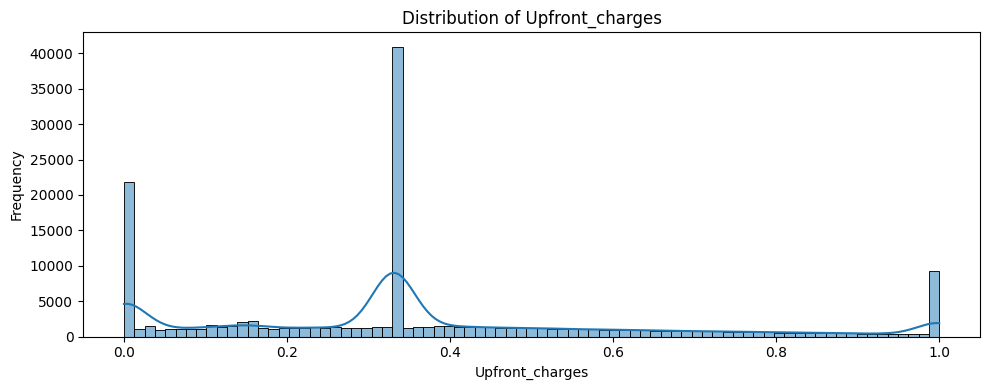

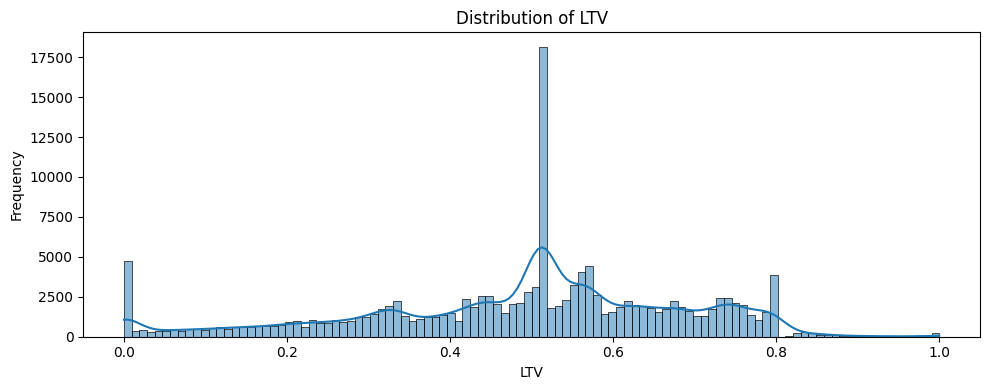

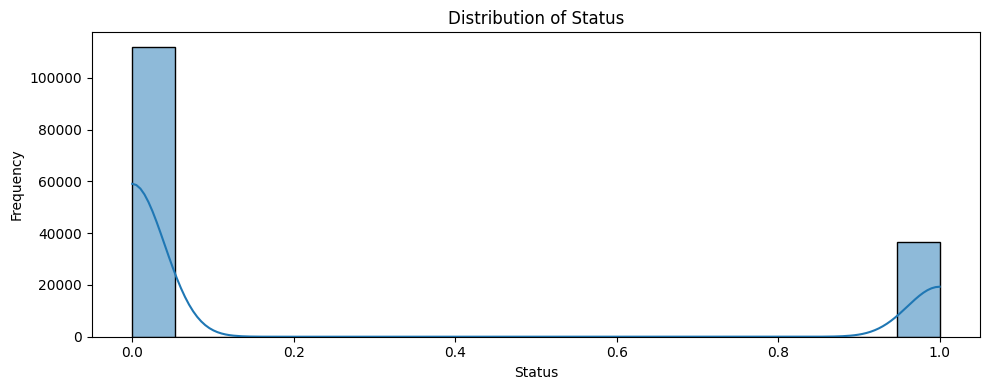

In [33]:
# 15 Plot distributions for numeric columns
def plot_distributions(df):
    """Plot distributions for numeric columns in the DataFrame."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        plt.figure(figsize=(10, 4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
plot_distributions(df)

In [34]:
# 16 Plot count plots for categorical columns
def plot_categorical_counts(df):
    """Plot count plots for categorical columns in the DataFrame."""
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        plt.figure(figsize=(10, 4))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f'Count Plot of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
plot_categorical_counts(df)



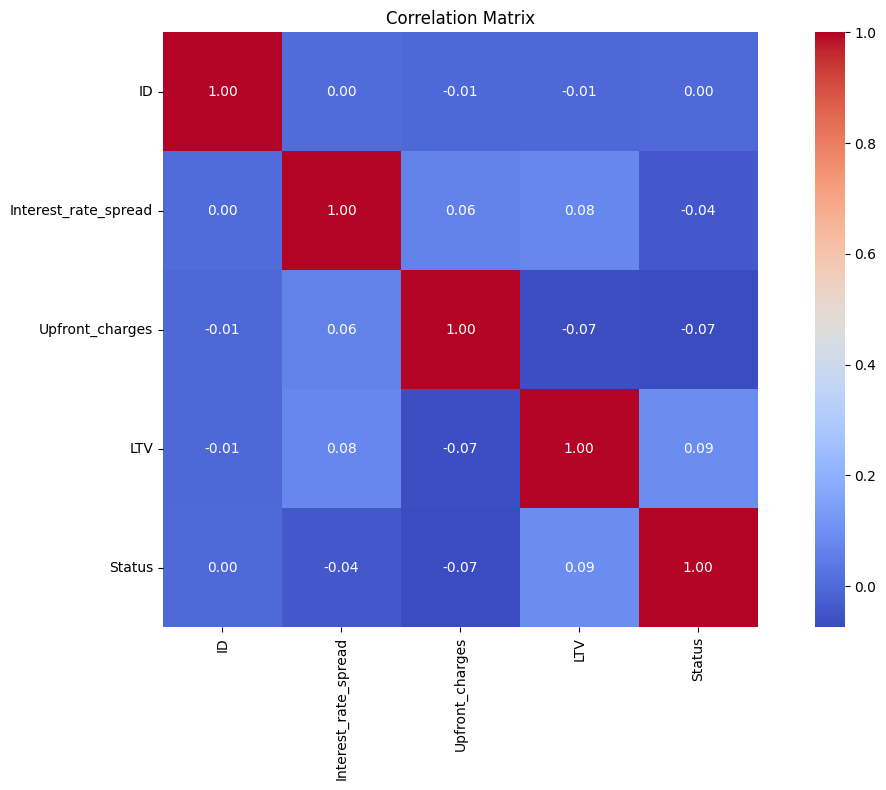

In [35]:
# 17 Correlation matrix for numeric columns
def correlation_matrix(df):
    """Plot the correlation matrix for numeric columns in the DataFrame."""
    numeric_cols = df.select_dtypes(include=[np.number])
    corr = numeric_cols.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
correlation_matrix(df)



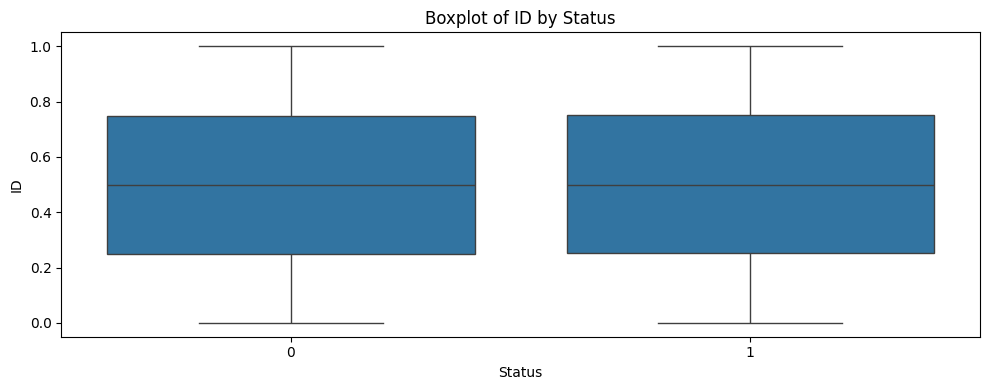

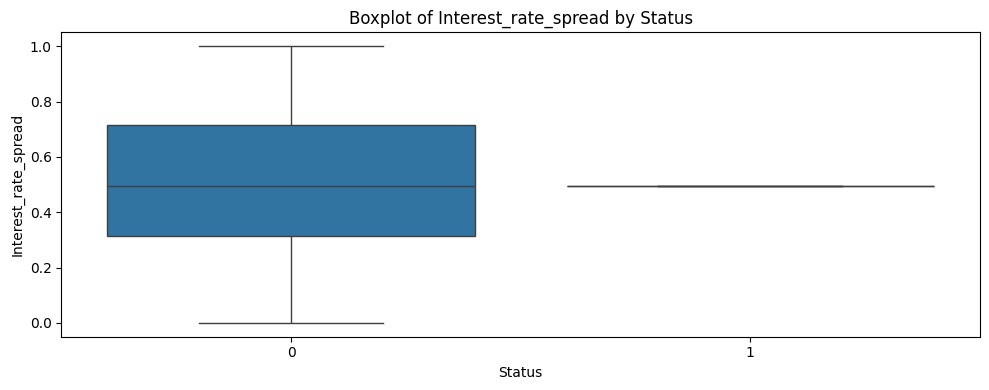

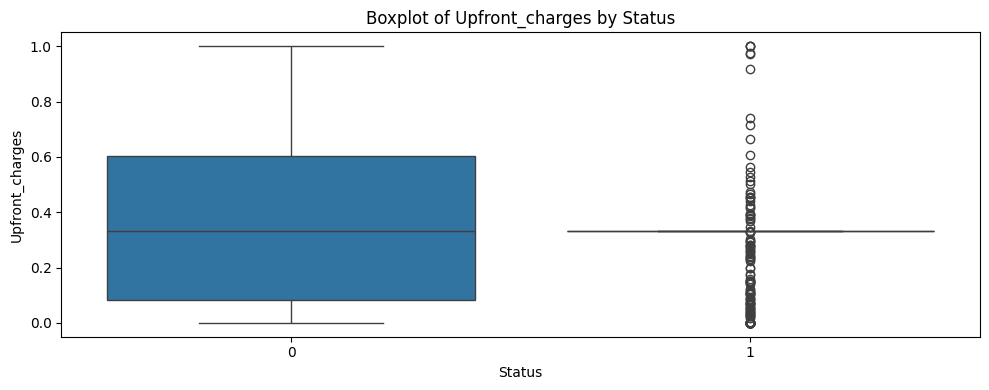

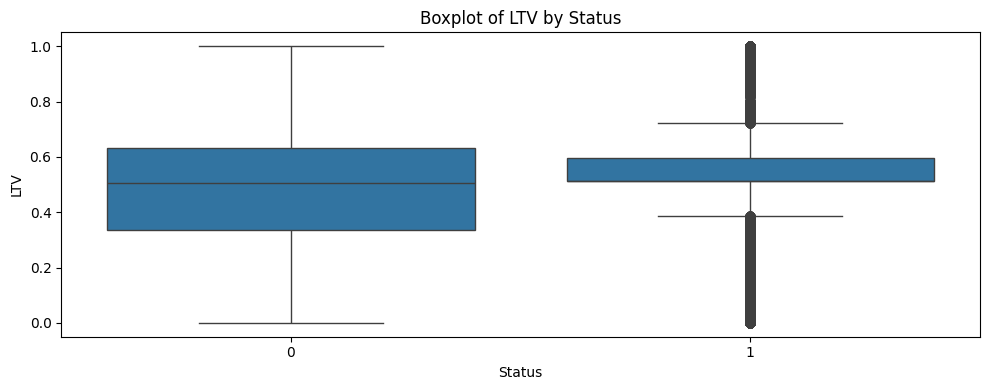

In [36]:
# 18 Status vs numeric features(Boxplots)
def plot_box_by_target(df, target='Status'):
    """Plot boxplots of numeric features grouped by the target variable."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != target]
    for col in numeric_cols:
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f'Boxplot of {col} by {target}')
        plt.xlabel(target)
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
plot_box_by_target(df)

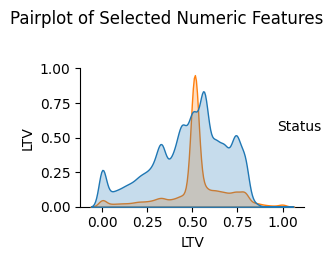

In [37]:
# 19 Pairplot of numeric features
def plot_pairplot(df, target='Status'):
    """Plot pairplot of numeric features colored by the target variable."""
    top_cols = ['loan_amount', 'rate_of_interest', 'LTV','income', target]
    existing = [col for col in top_cols if col in df.columns]
    if len(existing) >= 2:
        sns.pairplot(df[existing], hue=target, diag_kind='kde')
        plt.suptitle('Pairplot of Selected Numeric Features', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough numeric columns for pairplot.")
plot_pairplot(df)



In [38]:
# 20 interactive plots with plotly
import plotly.express as px
def interactive_scatter_plot(df, x, y, color=None):
    """Create an interactive scatter plot using Plotly."""
    if 'loan_amount' in df.columns and 'income' in df.columns:
        fig = px.scatter(df, x=x, y=y, color=color, title=f'Interactive Scatter Plot of {y} vs {x}')
        fig.show()
    if 'rate_of_interest' in df.columns and 'LTV' in df.columns:
        fig = px.scatter(df, x='rate_of_interest', y='LTV', color=color, title='Interactive Scatter Plot of LTV vs Rate of Interest')
        fig.show()
    if 'loan_amount' in df.columns and 'Status' in df.columns:
        fig = px.histogram(df, x='loan_amount', color=color, title='Interactive Histogram of Loan Amount by Status', barmode='group')
        fig.show()
    if 'rate_of_interest' in df.columns and 'Status' in df.columns:
        fig = px.histogram(df, x='rate_of_interest', color=color, title='Interactive Histogram of Rate of Interest by Status', barmode='group')
        fig.show()
    if 'rate_of_interest' in df.columns and 'income' in df.columns:
        fig = px.box(df, x=color, y='rate_of_interest', title='Interactive Box Plot of Rate of Interest by Status')
        fig.show()
interactive_scatter_plot(df, x='loan_amount', y='income', color='Status')




In [39]:
# 21 Save visualizations
def save_visualizations(df):
    """Save key visualizations as image files."""
    # Example: Save correlation matrix
    numeric_cols = df.select_dtypes(include=[np.number])
    corr = numeric_cols.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig("correlation_matrix.png")
    plt.close()
    print(" Visualizations saved as image files.")
save_visualizations(df)



 Visualizations saved as image files.


In [40]:
# 22 Export summary statistics
def export_summary_statistics(df, numeric_file='numeric_summary.csv', categorical_file='categorical_summary.csv'):
    """Export summary statistics to CSV files."""
    numeric_stats = numeric_summary(df)
    numeric_stats.to_csv(numeric_file)
    categorical_stats = categorical_summary(df)
    categorical_stats.to_csv(categorical_file)
    print(f" Summary statistics exported: {numeric_file}, {categorical_file}")
export_summary_statistics(df)

 No categorical columns found (likely after encoding).
 Summary statistics exported: numeric_summary.csv, categorical_summary.csv


In [41]:
#train test split
from sklearn.model_selection import train_test_split
X = df.drop('Status', axis=1)
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Save train and test sets
def save_train_test_sets(X_train, X_test, y_train, y_test, prefix='loan_default'):
    """Save train and test sets to CSV files."""
    train = pd.concat([X_train, y_train], axis=1)
    test = pd.concat([X_test, y_test], axis=1)
    train.to_csv(f"{prefix}_train.csv", index=False)
    test.to_csv(f"{prefix}_test.csv", index=False)
    print(f" Train and test sets saved: {prefix}_train.csv, {prefix}_test.csv")
save_train_test_sets(X_train, X_test, y_train, y_test)

Train shape: (118936, 17) Test shape: (29734, 17)
 Train and test sets saved: loan_default_train.csv, loan_default_test.csv


In [42]:

#train linear regression model as a test
from sklearn.linear_model import LinearRegression
def train_linear_regression(X_train, y_train, X_test, y_test):
    """Train and evaluate a linear regression model."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" Linear Regression Train R^2: {train_score:.4f}, Test R^2: {test_score:.4f}")
train_linear_regression(X_train, y_train, X_test, y_test)


#train logistic regression model as a test
from sklearn.linear_model import LogisticRegression
def train_logistic_regression(X_train, y_train, X_test, y_test):
    """Train and evaluate a logistic regression model."""
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" Logistic Regression Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_logistic_regression(X_train, y_train, X_test, y_test)


#train decision tree model as a test
from sklearn.tree import DecisionTreeClassifier
def train_decision_tree(X_train, y_train, X_test, y_test):
    """Train and evaluate a decision tree classifier."""
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" Decision Tree Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_decision_tree(X_train, y_train, X_test, y_test)

 Linear Regression Train R^2: 0.1287, Test R^2: 0.1401
 Logistic Regression Train Accuracy: 0.7713, Test Accuracy: 0.7764
 Decision Tree Train Accuracy: 1.0000, Test Accuracy: 1.0000


In [47]:
#train random forest model as a test
from sklearn.ensemble import RandomForestClassifier
def train_random_forest(X_train, y_train, X_test, y_test):
    """Train and evaluate a random forest classifier."""
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" Random Forest Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_random_forest(X_train, y_train, X_test, y_test)

#hyperparameter tuning with grid search for random forest
from sklearn.model_selection import GridSearchCV
def hyperparameter_tuning_rf(X_train, y_train):
    """Perform hyperparameter tuning for Random Forest using GridSearchCV."""
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    print(" Best parameters found:", grid_search.best_params_)
    print(" Best cross-validation accuracy:", grid_search.best_score_)
hyperparameter_tuning_rf(X_train, y_train)



 Random Forest Train Accuracy: 1.0000, Test Accuracy: 0.9999
 Best parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
 Best cross-validation accuracy: 0.9999888423988843


In [44]:
# train knn model as a test
from sklearn.neighbors import KNeighborsClassifier
def train_knn(X_train, y_train, X_test, y_test, n_neighbors=5):
    """Train and evaluate a K-Nearest Neighbors classifier."""
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" KNN (k={n_neighbors}) Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_knn(X_train, y_train, X_test, y_test, n_neighbors=5)

# train naive bayes model as a test
from sklearn.naive_bayes import GaussianNB
def train_naive_bayes(X_train, y_train, X_test, y_test):
    """Train and evaluate a Gaussian Naive Bayes classifier."""
    model = GaussianNB()
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" Naive Bayes Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_naive_bayes(X_train, y_train, X_test, y_test)

 KNN (k=5) Train Accuracy: 0.9792, Test Accuracy: 0.9718
 Naive Bayes Train Accuracy: 0.7709, Test Accuracy: 0.7737


In [45]:
#handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
def apply_smote(X_train, y_train):
    """Apply SMOTE to balance the training dataset."""
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print(" After SMOTE, class distribution:\n", pd.Series(y_res).value_counts())
    return X_res, y_res
X_train, y_train = apply_smote(X_train, y_train)

#train balanced random forest model as a test
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import EasyEnsembleClassifier
def train_balanced_random_forest(X_train, y_train, X_test, y_test):
    """Train and evaluate a Balanced Random Forest classifier."""
    model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" Balanced Random Forest Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_balanced_random_forest(X_train, y_train, X_test, y_test)

 After SMOTE, class distribution:
 Status
0    89625
1    89625
Name: count, dtype: int64
 Balanced Random Forest Train Accuracy: 1.0000, Test Accuracy: 0.9999


In [50]:
!pip install catboost
!pip install lightgbm
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [51]:
# train xgboost model as a test
import xgboost as xgb
def train_xgboost(X_train, y_train, X_test, y_test):
    """Train and evaluate an XGBoost classifier."""
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" XGBoost Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_xgboost(X_train, y_train, X_test, y_test)

#train catboost model as a test
from catboost import CatBoostClassifier
def train_catboost(X_train, y_train, X_test, y_test):
    """Train and evaluate a CatBoost classifier."""
    model = CatBoostClassifier(verbose=0, random_state=42)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" CatBoost Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_catboost(X_train, y_train, X_test, y_test)


#train lightgbm model as a test
import lightgbm as lgb
def train_lightgbm(X_train, y_train, X_test, y_test):
    """Train and evaluate a LightGBM classifier."""
    model = lgb.LGBMClassifier(random_state=42)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" LightGBM Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_lightgbm(X_train, y_train, X_test, y_test)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:30:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost Train Accuracy: 1.0000, Test Accuracy: 0.9998
 CatBoost Train Accuracy: 1.0000, Test Accuracy: 1.0000
[LightGBM] [Info] Number of positive: 89625, number of negative: 89625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 179250, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

In [52]:
#train ensemble model as a test
from sklearn.ensemble import VotingClassifier
def train_ensemble_model(X_train, y_train, X_test, y_test):
    """Train and evaluate an ensemble voting classifier."""
    model1 = LogisticRegression(max_iter=1000)
    model2 = DecisionTreeClassifier(random_state=42)
    model3 = RandomForestClassifier(n_estimators=100, random_state=42)
    ensemble = VotingClassifier(estimators=[
        ('lr', model1),
        ('dt', model2),
        ('rf', model3)
    ], voting='hard')
    ensemble.fit(X_train, y_train)
    train_score = ensemble.score(X_train, y_train)
    test_score = ensemble.score(X_test, y_test)
    print(f" Ensemble Model Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_ensemble_model(X_train, y_train, X_test, y_test)

#train stacking model as a test
from sklearn.ensemble import StackingClassifier
def train_stacking_model(X_train, y_train, X_test, y_test):
    """Train and evaluate a stacking classifier."""
    estimators = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]
    stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
    stacking.fit(X_train, y_train)
    train_score = stacking.score(X_train, y_train)
    test_score = stacking.score(X_test, y_test)
    print(f" Stacking Model Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_stacking_model(X_train, y_train, X_test, y_test)

#train bagging model as a test
from sklearn.ensemble import BaggingClassifier
def train_bagging_model(X_train, y_train, X_test, y_test):
    """Train and evaluate a bagging classifier."""
    base_model = DecisionTreeClassifier(random_state=42)
    bagging = BaggingClassifier(estimator=base_model, n_estimators=50, random_state=42)
    bagging.fit(X_train, y_train)
    train_score = bagging.score(X_train, y_train)
    test_score = bagging.score(X_test, y_test)
    print(f" Bagging Model Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_bagging_model(X_train, y_train, X_test, y_test)



 Ensemble Model Train Accuracy: 1.0000, Test Accuracy: 1.0000
 Stacking Model Train Accuracy: 1.0000, Test Accuracy: 1.0000
 Bagging Model Train Accuracy: 1.0000, Test Accuracy: 1.0000


In [ ]:
#train mlp model as a test
from sklearn.neural_network import MLPClassifier
def train_mlp(X_train, y_train, X_test, y_test):
    """Train and evaluate a Multi-Layer Perceptron classifier."""
    model = MLPClassifier(hidden_layer_sizes=(100, ), max_iter=300, random_state=42)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f" MLP Classifier Train Accuracy: {train_score:.4f}, Test Accuracy: {test_score:.4f}")
train_mlp(X_train, y_train, X_test, y_test)

#train simple neural network model as a test
import tensorflow as tf
def train_simple_nn(X_train, y_train, X_test, y_test):
    """Train and evaluate a simple neural network using TensorFlow/Keras."""
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f" Simple NN Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
train_simple_nn(X_train, y_train, X_test, y_test)



In [ ]:
import shutil

shutil.copy("loan_default_train.csv", "/content/drive/MyDrive/")
shutil.copy("loan_default_test.csv", "/content/drive/MyDrive/")
shutil.copy("numeric_summary.csv", "/content/drive/MyDrive/")
shutil.copy("categorical_summary.csv", "/content/drive/MyDrive/")
shutil.copy("correlation_matrix.png", "/content/drive/MyDrive/")

